# Mesh Tutorial 7: Simulation Domains with DomainMesh

Boundary conditions determine the physics. Without them, a PDE isn't well-posed -
"solve Navier-Stokes on this mesh" is meaningless until you specify which walls are
no-slip, where the inflow is, and what the freestream velocity is.

The challenge is that interior and boundary data are **heterogeneous**:

- The **interior** is a triangulated volume or surface (`Mesh[2, 2]` or `Mesh[2, 3]`)
  carrying fields like pressure and velocity.
- Each **boundary** may be a different manifold dimension (`Mesh[1, 2]` curves,
  `Mesh[2, 3]` surfaces) with its own fields (wall shear, prescribed velocity).
- **Domain-level metadata** (Reynolds number, Mach number) applies globally.

`DomainMesh` groups these into a single tensorclass:

| Field | Type | Purpose |
|-------|------|----------|
| `interior` | `Mesh` | Volume mesh, point cloud, or prediction surface |
| `boundaries` | `dict[str, Mesh]` | Named boundary patches keyed by BC type |
| `global_data` | `dict[str, Tensor]` | Domain-level quantities (Re, Mach, etc.) |

Operations like rotation, scaling, and validation propagate automatically -
the interior, all boundaries, and their attached data move together.

---

## Why DomainMesh?

Production pipelines like GLOBE already need this pattern. DrivAerML manually
assembles a `prediction_mesh`, a `boundary_meshes: TensorDict[str, Mesh]` dict,
and separate `global_data` - then passes them around as loose fields. Every new
model reimplements this bundling.

`DomainMesh` standardizes it at a **model-agnostic** level: not prescriptive in
how you use boundary info in your model, only in how you represent it. Key features:

- **`apply_to_meshes(fn)`**: Apply any `Mesh -> Mesh` function to all meshes at once
- **Geometric transforms**: `translate`, `rotate`, `scale` with optional vector-field
  co-rotation - enabling on-the-fly data augmentation for quasi-equivariance
- **Serialization**: Saves/loads like a `Mesh`, with a directory structure that
  allows on-disk surgery on individual components
- **Validation**: Aggregate quality checks across the entire domain

In this tutorial we'll build a `DomainMesh` from a real AirFRANS CFD sample -
a 2D RANS simulation of flow around an airfoil.

## What You'll Learn

1. Load a real CFD domain from VTK files (interior + boundary meshes)
2. Project 3D simulation data to 2D and assemble into a `DomainMesh`
3. Inspect domain properties and iterate over meshes
4. Use geometric transforms for data augmentation (quasi-equivariance)
5. Validate mesh quality across the domain
6. Visualize the pressure field around the airfoil

In [1]:
from pathlib import Path

import pyvista as pv
import torch

from physicsnemo.mesh import DomainMesh, Mesh
from physicsnemo.mesh.io import from_pyvista
from physicsnemo.mesh.projections import project

## Section 1: Loading a Real CFD Domain

Each AirFRANS sample directory contains three VTK files from a 2D RANS simulation:

| File | Contents | Target type |
|------|----------|-------------|
| `*_internal.vtu` | Triangulated flow field with pressure, velocity, etc. | `Mesh[2, 2]` |
| `*_aerofoil.vtp` | Airfoil surface polyline (no-slip wall) | `Mesh[1, 2]` |
| `*_freestream.vtp` | Outer domain boundary polyline (far-field) | `Mesh[1, 2]` |

The VTK files are 3D (with a constant z-coordinate from the extrusion), so we
use `project(keep_dims=[0, 1])` to drop the z-axis and get proper 2D meshes.
This is the same loading pattern used by the GLOBE AirFRANS pipeline.

In [2]:
# Point this to any AirFRANS sample directory
SAMPLE_DIR = (
    Path.home()
    / "gh/aerodynamics_datasets/airfrans/Dataset"
    / "airFoil2D_SST_31.382_3.588_1.994_6.206_0.0_13.271"
)
base = SAMPLE_DIR.name

# Interior: triangulated flow field -> Mesh[2, 2]
# transform_point_data=True projects vector fields (e.g. velocity) alongside coordinates
raw_interior = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_internal.vtu"))),
    keep_dims=[0, 1],
    transform_point_data=True,
)

# Keep only the physics fields (strip VTK metadata like TimeValue, vtkOriginalPointIds)
interior = Mesh(
    points=raw_interior.points,
    cells=raw_interior.cells,
    point_data=raw_interior.point_data.select("p", "U", "nut"),
)
print(f"Interior:\n\n{interior}")

Interior:

Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=180790, n_cells=359058)
    point_data: {U: (2,), nut: (), p: ()}


In [3]:
# Airfoil boundary (no-slip wall) -> Mesh[1, 2]
# transform_point_data=True projects vector fields (U, Normals) from 3D to 2D
raw_airfoil = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_aerofoil.vtp")), manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
)
# Strip VTK metadata (TimeValue) from global_data
airfoil = Mesh(
    points=raw_airfoil.points,
    cells=raw_airfoil.cells,
    point_data=raw_airfoil.point_data,
    cell_data=raw_airfoil.cell_data,
)
print(f"Airfoil:\n\n{airfoil}")

Airfoil:

Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1018, n_cells=1018)
    point_data: {
        Normals: (2,),
        U      : (2,),
        nut    : (),
        p      : ()}
    cell_data : {
        Length : (),
        Normals: (3,),
        U      : (3,),
        nut    : (),
        p      : ()}


In [4]:
# Freestream boundary (far-field) -> Mesh[1, 2]
raw_freestream = project(
    from_pyvista(pv.read(str(SAMPLE_DIR / f"{base}_freestream.vtp")), manifold_dim=1),
    keep_dims=[0, 1],
    transform_point_data=True,
    transform_cell_data=True,
)
# Strip VTK metadata (TimeValue) from global_data
freestream = Mesh(
    points=raw_freestream.points,
    cells=raw_freestream.cells,
    point_data=raw_freestream.point_data,
    cell_data=raw_freestream.cell_data,
)
print(f"Freestream:\n\n{freestream}")

Freestream:

Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1728, n_cells=1728)
    point_data: {U: (2,), nut: (), p: ()}
    cell_data : {U: (2,), nut: (), p: ()}


### Assembling the Domain

The two boundary meshes represent the physical boundary conditions:

- **Airfoil** (no-slip wall): the solid body where velocity is zero
- **Freestream** (far-field): the outer domain boundary at the edge of the computational domain

Each boundary carries its own physics fields (`p`, `U`, `nut`) - this heterogeneity
is the whole point. The interior is a `Mesh[2, 2]` triangulation while the boundaries
are `Mesh[1, 2]` curves, each with data appropriate to its role.

Domain-level quantities like the freestream velocity vector `U_inf` go in `global_data`.

In [5]:
dm = DomainMesh(
    interior=interior,
    boundaries={
        "airfoil": airfoil,
        "freestream": freestream,
    },
    global_data={"U_inf": freestream.cell_data["U"].mean(dim=0)},
)

print(dm)

DomainMesh(
    interior: Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=180790, n_cells=359058)
        point_data: {U: (2,), nut: (), p: ()}
    boundaries:
        airfoil   : Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1018, n_cells=1018)
            point_data: {
                Normals: (2,),
                U      : (2,),
                nut    : (),
                p      : ()}
            cell_data : {
                Length : (),
                Normals: (3,),
                U      : (3,),
                nut    : (),
                p      : ()}
        freestream: Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1728, n_cells=1728)
            point_data: {U: (2,), nut: (), p: ()}
            cell_data : {U: (2,), nut: (), p: ()}
    global_data: {U_inf: (2,)}
)


## Section 2: Inspecting the Domain

A `DomainMesh` provides properties and iterators for exploring its contents.

In [6]:
# Access individual boundaries by name
print(f"{dm.boundaries['airfoil'] = }")

# Access domain-level metadata
U_inf = dm.global_data["U_inf"]
print(f"U_inf = {U_inf}  (|U_inf| = {U_inf.norm():.2f} m/s)")

dm.boundaries['airfoil'] = Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1018, n_cells=1018)
    point_data: {
        Normals: (2,),
        U      : (2,),
        nut    : (),
        p      : ()}
    cell_data : {
        Length : (),
        Normals: (3,),
        U      : (3,),
        nut    : (),
        p      : ()}
U_inf = tensor([31.3015,  1.9567])  (|U_inf| = 31.36 m/s)


In [7]:
# Iterate over all meshes: interior first, then boundaries in sorted order
for name, mesh in dm:
    print(f"{name}:\n{mesh}\n")

interior:
Mesh[n_manifold_dims=2, n_spatial_dims=2](n_points=180790, n_cells=359058)
    point_data: {U: (2,), nut: (), p: ()}

airfoil:
Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1018, n_cells=1018)
    point_data: {
        Normals: (2,),
        U      : (2,),
        nut    : (),
        p      : ()}
    cell_data : {
        Length : (),
        Normals: (3,),
        U      : (3,),
        nut    : (),
        p      : ()}

freestream:
Mesh[n_manifold_dims=1, n_spatial_dims=2](n_points=1728, n_cells=1728)
    point_data: {U: (2,), nut: (), p: ()}
    cell_data : {U: (2,), nut: (), p: ()}



## Section 3: Data Augmentation via Geometric Transforms

For non-equivariant model architectures (like GeoTransolver), a practical way to
improve generalization is **data augmentation**: present the same physical problem
at different orientations during training. This requires rotating or translating the
entire domain - geometry, boundary conditions, and vector-valued data - consistently.

`DomainMesh` makes this a one-liner. All transform methods (`translate`, `rotate`,
`scale`, `transform`) propagate to the interior and every boundary mesh.
To co-rotate vector fields with the geometry, pass a dict specifying which fields
are spatial vectors (e.g. `transform_point_data={"U": True}`).

In [8]:
# Rotate the entire domain by 0.1 radians,
# co-rotating velocity fields and the freestream vector
dm_rotated = dm.rotate(
    angle=0.1,
    transform_point_data={"U": True},
    transform_global_data={"U_inf": True},
)

# Both geometry and vector data were rotated together
print("Freestream velocity (U_inf):")
print(f"  Original: {dm.global_data['U_inf']}")
print(f"  Rotated:  {dm_rotated.global_data['U_inf']}")
print()
print("Interior velocity at point 0:")
print(f"  Original: {dm.interior.point_data['U'][0]}")
print(f"  Rotated:  {dm_rotated.interior.point_data['U'][0]}")

Freestream velocity (U_inf):
  Original: tensor([31.3015,  1.9567])
  Rotated:  tensor([30.9498,  5.0719])

Interior velocity at point 0:
  Original: tensor([31.3106,  1.5947])
  Rotated:  tensor([30.9950,  4.7126])


In [9]:
# Fluent chaining: apply multiple transforms in one expression
dm_transformed = dm.translate([1.0, 0.0]).rotate(angle=0.2).scale(2.0)

# All meshes moved together
for name, mesh in dm_transformed:
    centroid = mesh.points.mean(dim=0)
    print(f"  {name:12s}: centroid = [{centroid[0]:.2f}, {centroid[1]:.2f}]")

  interior    : centroid = [2.94, 0.61]
  airfoil     : centroid = [2.71, 0.56]
  freestream  : centroid = [89.85, 21.45]


## Section 4: Validation

`DomainMesh.validate()` runs mesh quality checks on the interior and every boundary,
aggregating results into a single domain-level report.

In [10]:
report = dm.validate()
print(f"Domain valid: {report['valid']}")
print(f"  Interior:    {report['interior']['valid']}")
if not report["interior"]["valid"]:
    print(f"    degenerate cells: {report['interior']['n_degenerate_cells']}")
for name, bc_report in report["boundaries"].items():
    print(f"  {name:12s}: {bc_report['valid']}")

Domain valid: False
  Interior:    False
    degenerate cells: 599
  airfoil     : True
  freestream  : True


The interior mesh has several hundred degenerate (zero-area) cells - an artifact of
projecting the 3D extruded mesh to 2D. The boundary curves validate cleanly.

## Section 5: Visualization

`DomainMesh.draw()` draws the interior mesh with optional scalar coloring and
overlays all boundary curves automatically.  It returns the canvas (a
matplotlib `Axes` or PyVista `Plotter`), so you can set axis limits afterwards
to zoom into a subregion - essential here, since the domain spans [-200, 200]
but the airfoil is only ~1 unit.

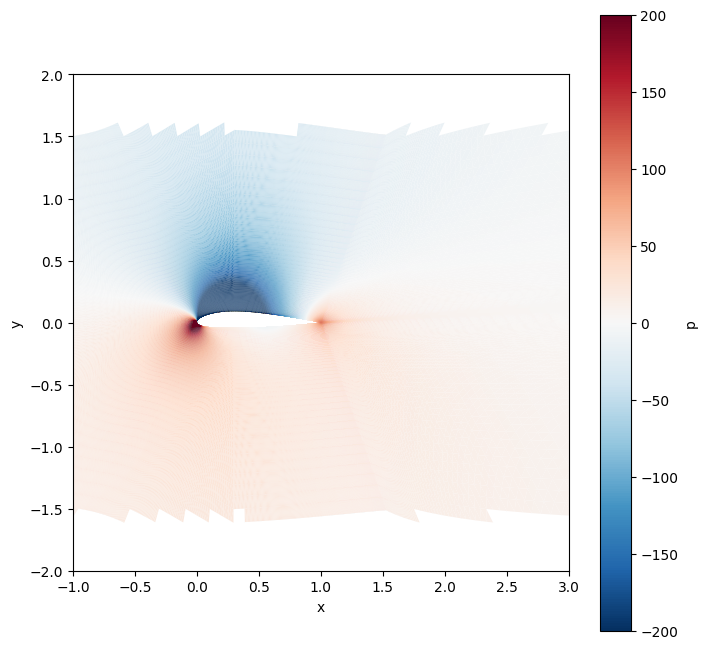

In [11]:
import matplotlib.pyplot as plt

# Pressure field near the airfoil, with boundary curves overlaid
ax = dm.draw(
    point_scalars="p",
    cmap="RdBu_r",
    vmin=-200,
    vmax=200,
    backend="matplotlib",
    show=False,
)
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 2)
plt.show()

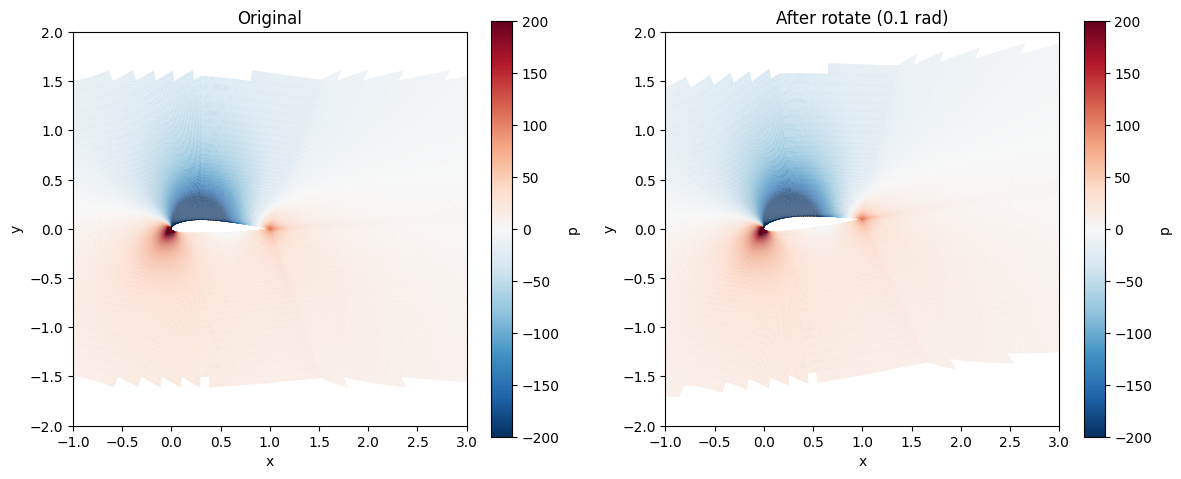

In [12]:
# Side-by-side: original vs rotated domain (from Section 3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

dm.draw(
    point_scalars="p",
    cmap="RdBu_r",
    vmin=-200,
    vmax=200,
    backend="matplotlib",
    ax=ax1,
    show=False,
)
ax1.set_xlim(-1, 3)
ax1.set_ylim(-2, 2)
ax1.set_title("Original")

dm_rotated.draw(
    point_scalars="p",
    cmap="RdBu_r",
    vmin=-200,
    vmax=200,
    backend="matplotlib",
    ax=ax2,
    show=False,
)
ax2.set_xlim(-1, 3)
ax2.set_ylim(-2, 2)
ax2.set_title("After rotate (0.1 rad)")

plt.tight_layout()
plt.show()

## Section 6: Spatial Queries

The `physicsnemo.mesh.sampling` module provides spatial query primitives:

- `match_points(source, target, tolerance)` - find coincident vertices
  between two point sets (KNN + tolerance filter)
- `knn(points, queries, k)` - k-nearest neighbor search

These compose naturally with `DomainMesh` for tasks like computing wall
distance or scattering boundary data onto the interior.

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/home/psharpe/gh/physicsnemo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Airfoil vertices matched to interior: 1018 / 1018


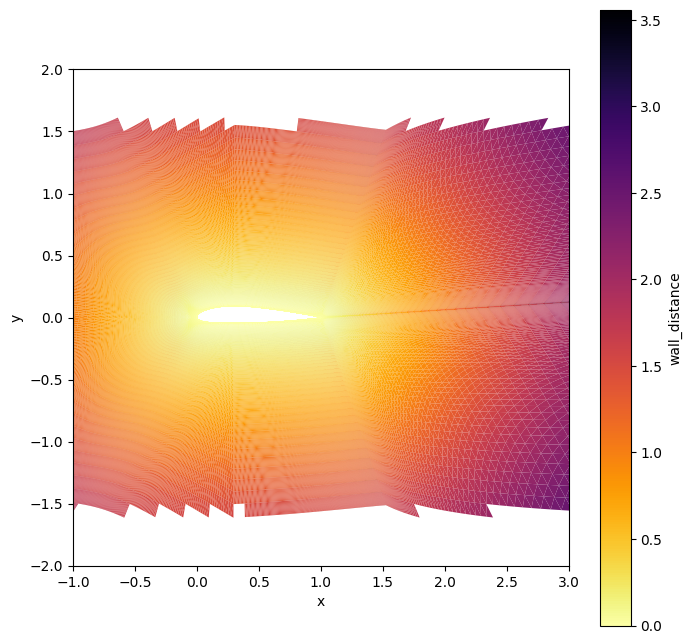

In [13]:
# Scatter airfoil normals onto the interior mesh using match_points
from physicsnemo.mesh.sampling import match_points
from physicsnemo.nn.functional.neighbors import knn

src_idx, tgt_idx = match_points(
    dm.boundaries["airfoil"].points,
    dm.interior.points,
    tolerance=1e-6,
)
print(
    f"Airfoil vertices matched to interior: {len(src_idx)} / {dm.boundaries['airfoil'].n_points}"
)

# Wall distance via KNN: nearest airfoil vertex for each interior point
airfoil_pts = dm.boundaries["airfoil"].points
_, dist = knn(points=airfoil_pts, queries=dm.interior.points, k=1)
dm.interior.point_data["wall_distance"] = dist[:, 0]

# Visualize
ax = dm.draw(
    point_scalars="wall_distance",
    cmap="inferno_r",
    backend="matplotlib",
    show=False,
)
ax.set_xlim(-1, 3)
ax.set_ylim(-2, 2)
plt.show()

## Summary

`DomainMesh` provides a standardized representation for simulation domains:

- **Three fields**: `interior` (the mesh), `boundaries` (named BC patches),
  `global_data` (domain parameters)
- **`draw()`**: One-line visualization with interior scalar coloring and boundary
  overlays; zoom by setting axis limits on the returned canvas
- **`apply_to_meshes(fn)`**: Map any `Mesh -> Mesh` function over the entire domain; all
  built-in operations delegate here
- **Spatial queries**: `match_points` and `knn` compose with `DomainMesh`
  for wall distance, data scattering, and other cross-component operations
- **Data augmentation**: Geometric transforms with explicit field selection
  (e.g. `transform_point_data={"U": True}`) co-rotate vector fields for
  quasi-equivariance
- **Validation**: `validate()` aggregates quality checks; `is_boundary_watertight()`
  verifies boundary patches tile into a closed surface

This is the foundation for standardized PDE problem representations, enabling
reusable datapipes that work across datasets and model architectures.